# Notebook 05: Protein Embedding Generation

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook generates protein embeddings from amino acid sequences using the
pretrained ESM-2 protein language model.

The cleaned protein dataset prepared in the previous notebook is used as the
input. The generated embeddings provide numerical representations of protein
sequences, which capture important biological information and can be used in
advanced machine learning models.

These embeddings will later be combined with drug molecular fingerprints for
drug–target interaction prediction.

### Dataset

The input dataset for this notebook is:

`protein_cleaned.csv`

The dataset contains protein identifiers, protein names, amino acid sequences,
and sequence lengths generated during the protein analysis stage.

### Project Workflow

This notebook represents the fifth stage of the project:

1. Load the cleaned protein dataset.
2. Assess protein sequence quality.
3. Load the pretrained ESM-2 model.
4. Generate protein embeddings.
5. Analyse the generated embeddings.
6. Visualise the embeddings using PCA.
7. Save the generated embeddings for downstream machine learning models.

### Objectives

The objectives of this notebook are:

1. Prepare protein sequences for embedding generation.
2. Generate protein embeddings using the pretrained ESM-2 model.
3. Assess the quality of the generated embeddings.
4. Visualise protein embeddings in a lower-dimensional space.
5. Save protein embeddings for later integration with drug molecular features.

In [2]:
# 1. Import Required Libraries

import os
import sys
import subprocess
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

import torch

warnings.filterwarnings("ignore")

In [3]:
# 2. Set Up Project Directories

from google.colab import drive

drive.mount("/content/drive")


PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)


RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)


PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)


FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)


MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models"
)


RESULTS_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)


print("Project directories configured successfully.")

Mounted at /content/drive
Project directories configured successfully.


In [4]:
# 3. Load Protein Dataset

protein_data = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_PATH,
        "protein_cleaned.csv"
    )
)


print("Protein dataset loaded successfully.")

Protein dataset loaded successfully.


In [5]:
# 4. Dataset Overview

print("Dataset Shape:")
print(protein_data.shape)

print("\nColumn Names:")
print(protein_data.columns.tolist())

print("\nFirst Five Records:")
display(protein_data.head())

Dataset Shape:
(200, 6)

Column Names:
['ensembl_id', 'uniprot_id', 'protein_name', 'sequence', 'length', 'sequence_length_check']

First Five Records:


,ensembl_id,uniprot_id,protein_name,sequence,length,sequence_length_check
0,ENSG00000149295,A0A1Y8EK52,NaN,MDPLNLS,7,7
1,ENSG00000102468,A0A7P0PKG8,5-hydroxytryptamine receptor 2A,MHLCAISLDRYVAIQNPIHHSRFNSRTKAFLKIIAVWTISVGISMP...,308,308
2,ENSG00000022355,A0A1B0GU82,NaN,MRKSPGLSDCLWAWILLLSTLTGRRTSRKSHQNTDLYEVNEGKDVA...,70,70
3,ENSG00000183454,A0A6Q8PGD2,Glutamate receptor,MLKIMQDYDWHVFSLVTTIFPGYREFISFVKTTVDNSFVGWDMQNV...,1307,1307
4,ENSG00000108576,P31645,Sodium-dependent serotonin transporter,METTPLNSQKQLSACEDGEDCQENGVLQKVVPTPGDKVESGQISNG...,630,630


In [6]:
# 5. Protein Sequence Quality Assessment

print("Missing Values:")

display(
    protein_data.isnull().sum()
)


print("\nDuplicate Records:")

print(
    protein_data.duplicated().sum()
)


print("\nSequence Length Statistics:")

display(
    protein_data["length"].describe()
)

Missing Values:


,0
ensembl_id,0
uniprot_id,0
protein_name,73
sequence,0
length,0
sequence_length_check,0



Duplicate Records:
0

Sequence Length Statistics:


,length
count,200.000000
mean,535.995000
std,487.763324
min,7.000000
25%,193.750000
50%,423.000000
75%,643.250000
max,3086.000000


In [7]:
# 6. Install Required Packages

print("Installing required packages...")


!pip -q install transformers
!pip -q install sentencepiece
!pip -q install accelerate


print("Required packages installed successfully.")

Installing required packages...
Required packages installed successfully.


In [8]:
# Verify Package Installation

import transformers

print("Transformers Version:", transformers.__version__)
print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Transformers Version: 5.13.1
PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU: Tesla T4


In [9]:
# 7. Load Pretrained ESM-2 Model

from transformers import AutoTokenizer, EsmModel


MODEL_NAME = "facebook/esm2_t6_8M_UR50D"


print("Loading pretrained ESM-2 model...")


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


esm_model = EsmModel.from_pretrained(
    MODEL_NAME
)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


esm_model.to(device)


esm_model.eval()


print("Model loaded successfully.\n")

print(f"Model Name: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Embedding Dimension: {esm_model.config.hidden_size}")
print(f"Maximum Sequence Length: {tokenizer.model_max_length}")

Loading pretrained ESM-2 model...


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 31.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.

Model Name: facebook/esm2_t6_8M_UR50D
Device: cuda
Embedding Dimension: 320
Maximum Sequence Length: 1000000000000000019884624838656


In [13]:
# 7.1 Configure Sequence Processing Settings

MAX_LENGTH = 1024


print(
    f"Maximum protein sequence length used: {MAX_LENGTH}"
)

Maximum protein sequence length used: 1024


In [14]:
# 8. Generate Protein Embeddings

from tqdm.auto import tqdm

In [15]:
# 8.1 Function to Generate Single Protein Embedding

def generate_embedding(sequence):

    """
    Generate ESM-2 embedding for a single protein sequence.
    """

    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )


    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }


    with torch.no_grad():

        outputs = esm_model(
            **inputs
        )


    # Mean pooling across sequence tokens
    embedding = outputs.last_hidden_state.mean(
        dim=1
    )


    return embedding.cpu().numpy().flatten()

In [16]:
# 8.2 Generate Protein Embeddings

protein_embeddings = []

protein_ids = []


print("Generating protein embeddings...")


for index, row in tqdm(
    protein_data.iterrows(),
    total=len(protein_data)
):

    sequence = row["sequence"]


    embedding = generate_embedding(
        sequence
    )


    protein_embeddings.append(
        embedding
    )


    protein_ids.append(
        row["uniprot_id"]
    )


print("\nProtein embedding generation completed.")

Generating protein embeddings...


  0%|          | 0/200 [00:00<?, ?it/s]


Protein embedding generation completed.


In [17]:
# 8.3 Convert Embeddings to NumPy Array

protein_embeddings = np.array(
    protein_embeddings
)


print(
    "Embedding Shape:",
    protein_embeddings.shape
)

Embedding Shape: (200, 320)


In [18]:
# 8.4 Create Embedding Metadata

embedding_metadata = protein_data[
    [
        "ensembl_id",
        "uniprot_id",
        "protein_name",
        "length"
    ]
].copy()


embedding_metadata["embedding_index"] = range(
    len(embedding_metadata)
)


display(
    embedding_metadata.head()
)

,ensembl_id,uniprot_id,protein_name,length,embedding_index
0,ENSG00000149295,A0A1Y8EK52,NaN,7,0
1,ENSG00000102468,A0A7P0PKG8,5-hydroxytryptamine receptor 2A,308,1
2,ENSG00000022355,A0A1B0GU82,NaN,70,2
3,ENSG00000183454,A0A6Q8PGD2,Glutamate receptor,1307,3
4,ENSG00000108576,P31645,Sodium-dependent serotonin transporter,630,4


In [19]:
# 9. Embedding Quality Assessment

# Check for missing values

print("Checking missing values...")

print(
    np.isnan(protein_embeddings).sum()
)


Checking missing values...
0


In [20]:
# 9.1 Check Embedding Dimensions

print(
    "Number of proteins:",
    protein_embeddings.shape[0]
)

print(
    "Embedding features:",
    protein_embeddings.shape[1]
)

Number of proteins: 200
Embedding features: 320


In [21]:
# 9.2 Embedding Statistics

embedding_statistics = pd.DataFrame(
    protein_embeddings
)


display(
    embedding_statistics.describe()
)

,0,1,2,3,4,5,6,7,8,9,...,310,311,312,313,314,315,316,317,318,319
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,-0.046605,-0.107198,0.093791,0.117166,0.084454,-0.147427,0.005110,0.012193,-0.107740,-0.048963,...,0.061097,-0.037063,0.077385,0.175299,-0.061147,-0.059046,-0.060900,0.203896,-0.041223,0.035403
std,0.087492,0.112404,0.095371,0.134034,0.153475,0.091078,0.088898,0.067173,0.136046,0.087099,...,0.101252,0.076704,0.083393,0.094676,0.126384,0.143296,0.084612,0.134271,0.130808,0.103414
min,-0.389445,-0.662712,-0.341411,-0.311172,-0.455930,-0.409957,-0.384174,-0.193413,-0.455440,-0.257718,...,-0.208807,-0.276749,-0.169030,-0.047597,-0.414613,-0.510698,-0.269071,-0.077606,-0.483487,-0.236910
25%,-0.096658,-0.162420,0.040752,0.028814,-0.019534,-0.207685,-0.047111,-0.034698,-0.208176,-0.112801,...,-0.010254,-0.072420,0.019744,0.108964,-0.146923,-0.147125,-0.114372,0.110573,-0.128795,-0.029335
50%,-0.041460,-0.099023,0.097925,0.108393,0.094812,-0.144122,-0.001398,0.022848,-0.128927,-0.059882,...,0.062297,-0.028310,0.088223,0.165535,-0.040024,-0.050487,-0.072375,0.187133,-0.043919,0.033358
75%,0.018430,-0.036537,0.154171,0.196234,0.190692,-0.092095,0.063840,0.059140,-0.031611,0.013894,...,0.130538,0.011075,0.127348,0.229182,0.040517,0.033728,-0.012294,0.287884,0.043206,0.115427
max,0.208814,0.146944,0.347861,0.405866,0.417916,0.255436,0.202665,0.175113,0.382591,0.231360,...,0.494508,0.142773,0.255880,0.405958,0.174628,0.355392,0.271960,0.601530,0.296340,0.243399


In [23]:
# 10. Protein Embedding Visualisation

from sklearn.decomposition import PCA


print(
    "Starting PCA analysis of protein embeddings..."
)


pca = PCA(
    n_components=2,
    random_state=42
)


protein_embeddings_2d = pca.fit_transform(
    protein_embeddings
)


print(
    "PCA transformation completed successfully."
)

Starting PCA analysis of protein embeddings...
PCA transformation completed successfully.


In [24]:
# 10.1 Check PCA Output Dimensions


print(
    "Original embedding dimensions:",
    protein_embeddings.shape[1]
)


print(
    "Reduced dimensions:",
    protein_embeddings_2d.shape[1]
)

Original embedding dimensions: 320
Reduced dimensions: 2


In [25]:
# 10.2 Create PCA Visualisation Dataset


pca_results = pd.DataFrame(
    protein_embeddings_2d,
    columns=[
        "PC1",
        "PC2"
    ]
)


pca_results["uniprot_id"] = protein_ids


display(
    pca_results.head()
)

,PC1,PC2,uniprot_id
0,-0.601894,-1.698545,A0A1Y8EK52
1,1.598846,-0.565804,A0A7P0PKG8
2,-1.093989,-1.344454,A0A1B0GU82
3,0.003136,0.147229,A0A6Q8PGD2
4,-0.172023,-0.488272,P31645


In [26]:
# 10.3 Calculate Explained Variance


explained_variance = pca.explained_variance_ratio_


print(
    "Explained variance by PC1:",
    round(explained_variance[0] * 100, 2),
    "%"
)


print(
    "Explained variance by PC2:",
    round(explained_variance[1] * 100, 2),
    "%"
)


print(
    "Total explained variance:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

Explained variance by PC1: 29.52 %
Explained variance by PC2: 11.98 %
Total explained variance: 41.5 %


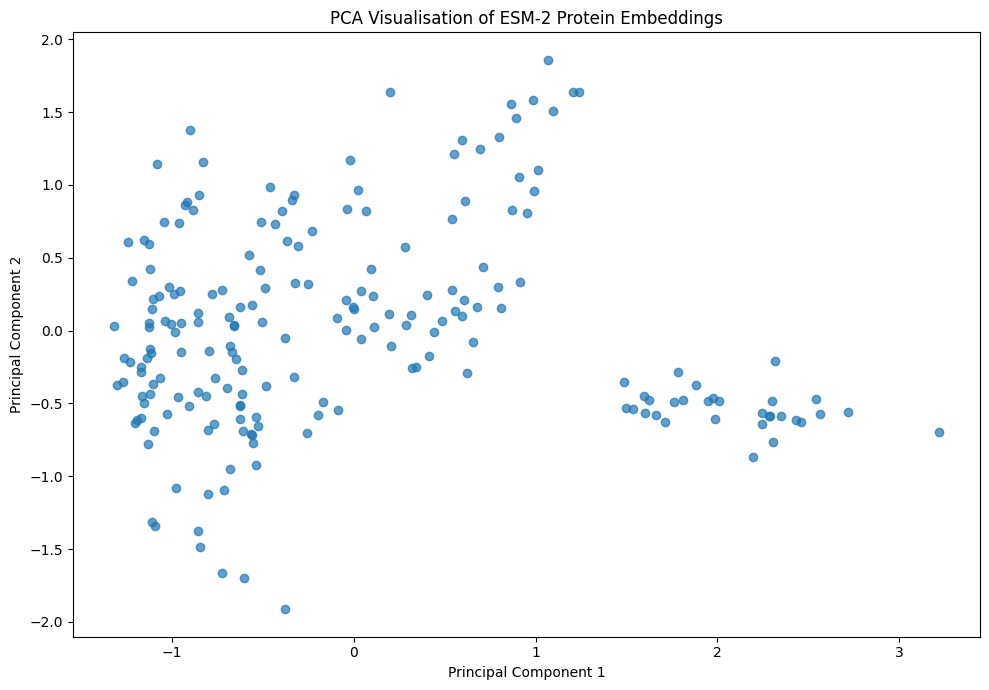

In [27]:
# 10.4 Plot Protein Embedding Space


plt.figure(
    figsize=(10, 7)
)


plt.scatter(
    pca_results["PC1"],
    pca_results["PC2"],
    alpha=0.7
)


plt.title(
    "PCA Visualisation of ESM-2 Protein Embeddings"
)


plt.xlabel(
    "Principal Component 1"
)


plt.ylabel(
    "Principal Component 2"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "protein_embeddings_pca.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [28]:
# 11. Save Protein Embedding Array


embedding_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_embeddings.npy"
)


np.save(
    embedding_file,
    protein_embeddings
)


print(
    "Protein embeddings saved successfully."
)


print(
    embedding_file
)

Protein embeddings saved successfully.
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/processed/protein_embeddings.npy


In [29]:
# 11.1 Save Embedding Metadata


metadata_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_embedding_metadata.csv"
)


embedding_metadata.to_csv(
    metadata_file,
    index=False
)


print(
    "Embedding metadata saved successfully."
)


print(
    metadata_file
)

Embedding metadata saved successfully.
/content/drive/MyDrive/Dissertation/Depression-Drug-Target-AI/data/processed/protein_embedding_metadata.csv


In [32]:
# 12.Download Generated Files


from google.colab import files


# Download Protein Embeddings

files.download(embedding_file)


# Download Embedding Metadata


files.download(metadata_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary of Findings

This notebook generated protein sequence embeddings using the pretrained
ESM-2 deep learning model.

The protein sequences obtained from the processed protein dataset were
converted into numerical feature representations suitable for downstream
machine learning applications.

A total of 200 protein sequences were processed, producing 320-dimensional
embedding vectors for each protein.

The generated embeddings were evaluated by checking for missing values,
embedding dimensions, and statistical properties to ensure data quality.

Principal Component Analysis (PCA) was applied to visualise the high-dimensional
protein embedding space. The first two principal components explained 41.5% of
the total variance, providing a reduced representation of protein similarity
patterns.

The final protein embeddings and associated metadata were saved for integration
with drug-related features in subsequent stages of the project, including
drug–target interaction prediction and advanced machine learning models.